# 16.C21A/18.C21A Problem Set #1
Due Wednesday 8 April 2026

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Problem 1: The Finite Difference Matrix (5+5+5+5)

Consider the one-dimensional convection-diffusion equation:
$$\frac{\partial U}{\partial t} + u \frac{\partial U}{\partial x} = \mu \frac{\partial^2 U}{\partial x^2}, \qquad x \in [x_L, x_R], \quad t > 0.$$

Using _central differences_ for both the first and second spatial derivatives, we will explore the semi-discrete approximation of this equation, for a state vector $\mathbf{U}$ collecting our approximations $U_i$ of the solution at grid points indexed by $i$.  The semi-discrete equations can be written in matrix form as $\frac{d\mathbf{U}}{dt} = A\mathbf{U} + \mathbf{b},$ where $\mathbf{b}$ contains boundary data.

### **Solution Problem 1**

(a) Consider $N_x = 7$ grid points with constant velocity $u$ and diffusion $\mu$. A Dirichlet boundary condition $U_1 = U_{\text{inlet}}$ is applied at the left, and a first-order backward difference is used at the right boundary ($i = N_x$).

1. Write out the full $(N_x - 1) \times (N_x - 1)$ matrix $A$ and vector $\mathbf{b}$ explicitly, showing which entries are nonzero.
2. Identify which row of $A$ is *not* tridiagonal and explain why.
3. Write out the equation governing the last node $i = N_x$ when a backward difference is used for the convection term (with diffusion set to zero at the outflow).

#### Solution (a)

**Subproblem 1** With $N_x = 7$, the state vector is $\mathbf{U} = (U_2, U_3, \ldots, U_7)^T$ of size 6. Using uniform spacing $\Delta x$, define the central-difference stencil coefficients for interior nodes ($i = 2,\ldots,6$):

$$\alpha = \frac{u}{2\Delta x} + \frac{\mu}{\Delta x^2}, \qquad \beta = -\frac{2\mu}{\Delta x^2}, \qquad \gamma = -\frac{u}{2\Delta x} + \frac{\mu}{\Delta x^2}.$$

The semi-discrete equation at an interior node $i$ is:
$$\frac{dU_i}{dt} = \alpha\, U_{i-1} + \beta\, U_i + \gamma\, U_{i+1}.$$

At the right boundary we use first-order backward differences for *both* spatial derivatives (since no data exists to the right):

- Convection: $\;u\,U_x \approx u\,\frac{U_7 - U_6}{\Delta x}$
- Diffusion: $\;\mu\,U_{xx} \approx \mu\,\frac{U_7 - 2U_6 + U_5}{\Delta x^2}$

So the equation at node $i = 7$ is:
$$\frac{dU_7}{dt} = -\frac{u}{\Delta x}(U_7 - U_6) + \frac{\mu}{\Delta x^2}(U_7 - 2U_6 + U_5) = \frac{\mu}{\Delta x^2}\,U_5 + \left(\frac{u}{\Delta x} - \frac{2\mu}{\Delta x^2}\right) U_6 + \left(-\frac{u}{\Delta x} + \frac{\mu}{\Delta x^2}\right) U_7.$$

We obtain the following matrix $A$ and vector $b$:

$$A = \begin{pmatrix} \beta & \gamma & 0 & 0 & 0 & 0 \\ \alpha & \beta & \gamma & 0 & 0 & 0 \\ 0 & \alpha & \beta & \gamma & 0 & 0 \\ 0 & 0 & \alpha & \beta & \gamma & 0 \\ 0 & 0 & 0 & \alpha & \beta & \gamma \\ 0 & 0 & 0 & \frac{\mu}{\Delta x^2} & \frac{u}{\Delta x} - \frac{2\mu}{\Delta x^2} & -\frac{u}{\Delta x} + \frac{\mu}{\Delta x^2} \end{pmatrix}, \qquad \mathbf{b} = \begin{pmatrix} \alpha\, U_{\text{inlet}} \\ 0 \\ 0 \\ 0 \\ 0 \\ 0 \end{pmatrix}.$$

**Subproblem 2** The **last row** (row 6, corresponding to $i = 7$) is not tridiagonal. The entry $A_{6,4} = \mu/\Delta x^2$ sits two positions below the diagonal. This arises because the backward second-derivative stencil $(U_7 - 2U_6 + U_5)/\Delta x^2$ reaches back to $U_5 = U_{N_x - 2}$, which is two nodes to the left, one more than the central-difference stencil uses.

**Subproblem 3** Dropping the diffusion term at the outflow boundary:
$$\frac{dU_{N_x}}{dt} = -\frac{u}{\Delta x}\left(U_{N_x} - U_{N_x-1}\right).$$

This gives a tridiagonal last row: $A_{N-1,N-2} = u/\Delta x$, $A_{N-1,N-1} = -u/\Delta x$. This is the formulation used in part (b).

(b) Complete the function below that builds the matrix $A$ and vector $\mathbf{b}$ for the 1D convection-diffusion equation with:
- Left BC: Dirichlet ($U_1 = U_{\text{inlet}}$, removed from the state vector)
- Right BC: Backward difference at $i = N_x$ (convection only, no diffusion at outflow)

The state vector is $\mathbf{U} = (U_2, U_3, \ldots, U_{N_x})^T$ (size $N_x - 1$).

#### Solution (b)

In [47]:
def build_convdiff_matrix(Nx, dx, u, mu, U_inlet):
    N = Nx - 1
    A = np.zeros((N, N))
    b = np.zeros(N)

    alpha = u / (2 * dx) + mu / dx**2
    beta  = -2 * mu / dx**2
    gamma = -u / (2 * dx) + mu / dx**2

    # Interior rows (k=1..N-2)
    for k in range(1, N - 1):
        A[k, k - 1] = alpha
        A[k, k]     = beta
        A[k, k + 1] = gamma

    # First row (k=0, node i=2): U_{i-1}=U_inlet goes to b
    A[0, 0] = beta
    A[0, 1] = gamma
    b[0]    = alpha * U_inlet

    # Last row (k=N-1, node i=Nx): backward diff convection, no diffusion
    A[N - 1, N - 2] = u / dx
    A[N - 1, N - 1] = -u / dx

    return A, b


# Verification
Nx_test = 7
dx_test = 1.0
u_test = 1.0
mu_test = 0.1
UL_test = 1.0

A_test, b_test = build_convdiff_matrix(Nx_test, dx_test, u_test, mu_test, UL_test)
print("Matrix A:")
print(np.array2string(A_test, precision=3, suppress_small=True))
print("\nVector b:")
print(np.array2string(b_test, precision=3, suppress_small=True))
print(f"\nExpected size: {Nx_test-1} x {Nx_test-1}")

Matrix A:
[[-0.2 -0.4  0.   0.   0.   0. ]
 [ 0.6 -0.2 -0.4  0.   0.   0. ]
 [ 0.   0.6 -0.2 -0.4  0.   0. ]
 [ 0.   0.   0.6 -0.2 -0.4  0. ]
 [ 0.   0.   0.   0.6 -0.2 -0.4]
 [ 0.   0.   0.   0.   1.  -1. ]]

Vector b:
[0.6 0.  0.  0.  0.  0. ]

Expected size: 6 x 6


(c) A surprisingly common bug in finite difference codes is to construct $A$ correctly but *forget to include the boundary vector* $\mathbf{b}$. This effectively imposes $U_{\text{inlet}} = 0$ regardless of the true boundary value. Simulate the 1D convection-diffusion equation with $u = 1$, $\mu = 0.02$, and initial condition $U_0(x) = e^{-x^2}$ on $[-4, 4]$ using Forward Euler (FTCS). Run two simulations:
1. Correct: Include the $\mathbf{b}$ vector properly.
2. Buggy: Set $\mathbf{b} = \mathbf{0}$ (forgetting the boundary contribution).

Produce space-time contour plots (2D heatmaps with $x$ on the horizontal axis and $t$ on the vertical axis) for both cases side by side.

Use CFL = 0.1 so that the method is stable (the diffusion helps here).

**Choice for the parameters:**
- $N_x = 101$
- $t_f = 6$
- $U_{\text{inlet}} = 1$. This is deliberately **incompatible** with the IC ($U_0(x_L) = e^{-16} \approx 0$), creating a jump discontinuity at $(x_L, t=0)$. For $\mu > 0$ (parabolic equation), this is a well-posed choice: diffusion instantly smooths the discontinuity into a thin boundary layer. We choose this value because it makes the difference between the correct and buggy simulations dramatically visible in the heatmaps; with the IC-consistent value $e^{-16} \approx 0$, the two simulations would be visually indistinguishable.

#### Solution (c)

In [4]:
# Parameters
Nx = 101;  u = 1.0;  mu = 0.02;  CFL = 0.1;  tf = 6.0
xL, xR = -4.0, 4.0
dx = (xR - xL) / (Nx - 1)
dt = CFL * dx / u
Nt = int(np.ceil(tf / dt))
U_inlet = 1.0

x_full = np.linspace(xL, xR, Nx)
x = x_full[1:]  # state grid (nodes 2..Nx)

A, b = build_convdiff_matrix(Nx, dx, u, mu, U_inlet)
b_zero = np.zeros_like(b)

# Initial condition on state grid
U0 = np.exp(-x**2)

# Forward Euler with snapshot storage
save_every = max(1, Nt // 200)
t_save = [0.0]

U_correct = U0.copy();  U_buggy = U0.copy()
snap_correct = [np.concatenate(([U_inlet], U_correct))]
snap_buggy   = [np.concatenate(([0.0],     U_buggy))]

for n in range(Nt):
    U_correct += dt * (A @ U_correct + b)
    U_buggy   += dt * (A @ U_buggy + b_zero)
    if (n + 1) % save_every == 0 or n == Nt - 1:
        snap_correct.append(np.concatenate(([U_inlet], U_correct)))
        snap_buggy.append(np.concatenate(([0.0],      U_buggy)))
        t_save.append((n + 1) * dt)

snap_correct = np.array(snap_correct)
snap_buggy   = np.array(snap_buggy)
t_save = np.array(t_save)

# Side-by-side heatmaps
vmin = min(snap_correct.min(), snap_buggy.min())
vmax = max(snap_correct.max(), snap_buggy.max())

fig, (ax1, ax2, cax) = plt.subplots(1, 3, figsize=(13, 5),
    gridspec_kw={'width_ratios': [1, 1, 0.04], 'wspace': 0.25})
for ax, data, title in zip([ax1, ax2], [snap_correct, snap_buggy],
                            ['Correct (with b)', 'Buggy (b = 0)']):
    im = ax.pcolormesh(x_full, t_save, data, shading='auto', vmin=vmin, vmax=vmax, cmap='viridis')
    ax.set_xlabel('x');  ax.set_title(title)
ax1.set_ylabel('t');  ax2.set_yticks([])
fig.colorbar(im, cax=cax, label='U')
plt.show()

NameError: name 'build_convdiff_matrix' is not defined

(d) Quantify the error:

1. Compute the $L^2$ error between the correct and buggy solutions at each saved time step:
$$\|e(t)\|_2 = \sqrt{\Delta x \sum_i \left(U_i^{\text{correct}}(t) - U_i^{\text{buggy}}(t)\right)^2}$$
2. Plot this error as a function of time.
3. Why does the error originate at the left boundary and propagate inward? At what speed does the error front travel? Connect this to the convection velocity $u$ and also the role of diffusion in spreading the error.

#### Solution (d)

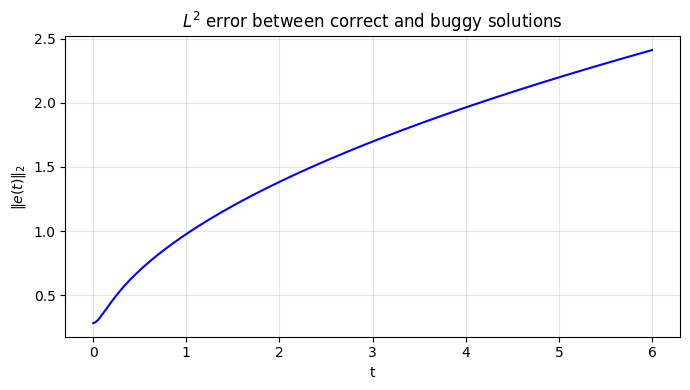

In [51]:
# L2 error vs time
L2_err = np.sqrt(dx * np.sum((snap_correct - snap_buggy)**2, axis=1))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t_save, L2_err, 'b-', lw=1.5)
ax.set_xlabel('t');  ax.set_ylabel(r'$\|e(t)\|_2$')
ax.set_title('$L^2$ error between correct and buggy solutions')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

The error originates at the **left boundary** because that is the only place the two simulations differ: the correct simulation applies $\mathbf{b}$ (encoding $U_{\text{inlet}} = 1$) while the buggy one effectively sets $U_{\text{inlet}} = 0$. This mismatch creates a local error at $x = x_L$ that is then transported into the domain.

## Problem 2: Boundary Conditions (5+5+5+5)
In this problem, we explore how different boundary condition treatments affect the solution quality, matrix structure, and convergence order. We work with the 1D convection equation (with optional small diffusion for stability):
$$\frac{\partial U}{\partial t} + u \frac{\partial U}{\partial x} = \mu \frac{\partial^2 U}{\partial x^2}, \qquad u > 0.$$

### **Solution Problem 2**

(a) For $u > 0$, the left boundary is inflow (Dirichlet: $U_1 = U_{\text{inlet}}$) and the right is outflow. We compare two outflow treatments with the backward difference from Problem 1.

Neumann BC: $\;\partial U/\partial x\big|_{x_R} = 0$, discretized as $U_{N_x} = U_{N_x-1}$.

Robin BC: $\;U + \ell\,U_x = 0$ at $x_R$, discretized as $U_{N_x} = \frac{\ell}{\Delta x + \ell}\,U_{N_x-1}$.

1. Substitute each into the central-difference stencil at node $i = N_x - 1$ and write the modified row in $A$.
2. Show that Robin interpolates between Dirichlet ($\ell \to 0$: $U_{N_x} \to 0$) and Neumann ($\ell \to \infty$: $U_{N_x} \to U_{N_x-1}$).

#### Solution (a)

The central-difference stencil at the penultimate node $i = N_x - 1$ (with both convection and diffusion) is:

$$\frac{dU_{N_x-1}}{dt} = \alpha\, U_{N_x-2} + \beta\, U_{N_x-1} + \gamma\, U_{N_x},$$

where $\alpha = \frac{u}{2\Delta x} + \frac{\mu}{\Delta x^2}$, $\beta = -\frac{2\mu}{\Delta x^2}$, $\gamma = -\frac{u}{2\Delta x} + \frac{\mu}{\Delta x^2}$.

**1. Substitution into the stencil.**

**Neumann** ($U_{N_x} = U_{N_x-1}$): Substituting into the stencil above:

$$\frac{dU_{N_x-1}}{dt} = \alpha\, U_{N_x-2} + (\beta + \gamma)\, U_{N_x-1}.$$

So the modified last row has coefficient of $U_{N_x-2}$ is $\alpha = \frac{u}{2\Delta x} + \frac{\mu}{\Delta x^2}$, coefficient of $U_{N_x-1}$ is $\beta + \gamma = -\frac{u}{2\Delta x} - \frac{\mu}{\Delta x^2}$.

**Robin** ($U_{N_x} = r\, U_{N_x-1}$ where $r = \frac{\ell}{\Delta x + \ell}$): Substituting:

$$\frac{dU_{N_x-1}}{dt} = \alpha\, U_{N_x-2} + (\beta + r\gamma)\, U_{N_x-1}.$$

So the modified last row has: coefficient of $U_{N_x-2}$ is $\alpha$, coefficient of $U_{N_x-1}$ is $\beta + r\gamma = -\frac{2\mu}{\Delta x^2} + \frac{\ell}{\Delta x + \ell}\left(-\frac{u}{2\Delta x} + \frac{\mu}{\Delta x^2}\right)$.

**2. Robin interpolates between Dirichlet and Neumann.**

The Robin relation gives $U_{N_x} = \frac{\ell}{\Delta x + \ell}\,U_{N_x-1}$, where $r = \frac{\ell}{\Delta x + \ell}$.

- As $\ell \to 0$: $r \to 0$, so $U_{N_x} \to 0$ — this is a **Dirichlet** BC.
- As $\ell \to \infty$: $r \to 1$, so $U_{N_x} \to U_{N_x-1}$ — this is a **Neumann** BC ($U_x = 0$).

The modified diagonal entry $\beta + r\gamma$ continuously interpolates between $\beta$ (Dirichlet, $r=0$) and $\beta + \gamma$ (Neumann, $r=1$).

(b) Complete the three matrix constructors below. All use central differences for interior nodes with Dirichlet inflow $U_1 = U_{\text{inlet}}$ at the left. For Configs B and C, $U_{N_x}$ is eliminated via the outflow relation and substituted into the stencil at $i = N_x - 1$.

- Config A — Backward difference outflow: $dU_{N_x}/dt = -u(U_{N_x} - U_{N_x-1})/\Delta x$. $U_{N_x}$ is kept in the state vector $(U_2,\ldots,U_{N_x})$, size $N_x{-}1$.
- Config B — Neumann outflow: $U_x\big|_{x_R}=0 \;\Rightarrow\; U_{N_x}=U_{N_x-1}$. $U_{N_x}$ is eliminated; state vector $(U_2,\ldots,U_{N_x-1})$, size $N_x{-}2$.
- Config C — Robin outflow: $U+\ell\,U_x=0 \;\Rightarrow\; U_{N_x}=\frac{\ell}{\Delta x+\ell}U_{N_x-1}$. $U_{N_x}$ is eliminated; state vector $(U_2,\ldots,U_{N_x-1})$, size $N_x{-}2$.

#### Solution (b)

In [5]:
def build_convection_configA(Nx, dx, u, U_inlet):
    """Config A: Dirichlet inflow + backward diff outflow.
    Pure convection (mu = 0). State size: Nx-1."""
    N = Nx - 1
    A = np.zeros((N, N))
    b = np.zeros(N)
    c = u / (2 * dx)

    # Interior rows: central difference for convection
    for k in range(1, N - 1):
        A[k, k - 1] = c
        A[k, k + 1] = -c

    # First row (i=2): U_1 = U_inlet goes to b
    A[0, 1] = -c
    b[0]    = c * U_inlet

    # Last row (i=Nx): backward difference
    A[N - 1, N - 2] = u / dx
    A[N - 1, N - 1] = -u / dx

    return A, b


def build_convection_configB(Nx, dx, u, U_inlet):
    """Config B: Dirichlet inflow + Neumann outflow (dU/dx = 0 at x_R).
    Pure convection (mu = 0). U_Nx = U_{Nx-1}.
    State: [U_2, ..., U_{Nx-1}], size Nx-2."""
    N = Nx - 2
    A = np.zeros((N, N))
    b = np.zeros(N)
    c = u / (2 * dx)

    for k in range(1, N - 1):
        A[k, k - 1] = c
        A[k, k + 1] = -c

    # First row (i=2)
    A[0, 1] = -c
    b[0]    = c * U_inlet

    # Last row (i=Nx-1): substitute U_Nx = U_{Nx-1}
    # dU/dt = -u*(U_Nx - U_{Nx-2})/(2dx) = -u*(U_{Nx-1} - U_{Nx-2})/(2dx)
    A[N - 1, N - 2] = c
    A[N - 1, N - 1] = -c

    return A, b


def build_convection_configC(Nx, dx, u, U_inlet, ell):
    """Config C: Dirichlet inflow + Robin outflow (U + ell*dU/dx = 0 at x_R).
    Pure convection (mu = 0). U_Nx = r * U_{Nx-1}.
    State: [U_2, ..., U_{Nx-1}], size Nx-2."""
    N = Nx - 2
    A = np.zeros((N, N))
    b = np.zeros(N)
    c = u / (2 * dx)
    r = ell / (dx + ell)

    for k in range(1, N - 1):
        A[k, k - 1] = c
        A[k, k + 1] = -c

    # First row (i=2)
    A[0, 1] = -c
    b[0]    = c * U_inlet

    # Last row (i=Nx-1): substitute U_Nx = r * U_{Nx-1}
    # dU/dt = -u*(r*U_{Nx-1} - U_{Nx-2})/(2dx)
    A[N - 1, N - 2] = c
    A[N - 1, N - 1] = -c * r

    return A, b


# Quick test
Nx_t = 11
dx_t = 8.0 / (Nx_t - 1)
u_t = 1.0
UL_t = np.exp(-(-4.0)**2)
ell_t = 2.0 * dx_t

A_a, b_a = build_convection_configA(Nx_t, dx_t, u_t, UL_t)
A_b, b_b = build_convection_configB(Nx_t, dx_t, u_t, UL_t)
A_c, b_c = build_convection_configC(Nx_t, dx_t, u_t, UL_t, ell_t)

print(f"Config A (backward diff) matrix size:  {A_a.shape}")
print(f"Config B (Neumann)       matrix size:  {A_b.shape}")
print(f"Config C (Robin, ell={ell_t:.2f}) matrix size:  {A_c.shape}")
print(f"\nConfig A matrix:")
print(np.array2string(A_a, precision=3, suppress_small=True))
print(f"\nConfig B matrix:")
print(np.array2string(A_b, precision=3, suppress_small=True))
print(f"\nConfig C matrix:")
print(np.array2string(A_c, precision=3, suppress_small=True))

Config A (backward diff) matrix size:  (10, 10)
Config B (Neumann)       matrix size:  (9, 9)
Config C (Robin, ell=1.60) matrix size:  (9, 9)

Config A matrix:
[[ 0.    -0.625  0.     0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.625  0.    -0.625  0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.625  0.    -0.625  0.     0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.625  0.    -0.625  0.     0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.625  0.    -0.625  0.     0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.625  0.    -0.625  0.     0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.625  0.    -0.625  0.     0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.625  0.    -0.625  0.   ]
 [ 0.     0.     0.     0.     0.     0.     0.     0.625  0.    -0.625]
 [ 0.     0.     0.     0.     0.     0.     0.     0.     1.25  -1.25 ]]

Config B matrix:
[[ 0.    -0.625  0.     0.     0.     0.     0.     0.     0.   ]
 [ 0.625  0.    -0.625  0

(c) Run all three configurations (A: backward diff, B: Neumann, C: Robin with $\ell = 2\Delta x$) using Forward Euler with $N_x = 101$, $\mu = 0.005$, CFL $= 0.5$, and Gaussian IC $U_0(x) = e^{-x^2}$ on $[-4, 4]$ up to $t = 5.0$.

1. Plot all three solutions with the exact solution $U(x,5) = e^{-(x-5)^2}$, including a zoomed view near the outflow ($x \in [2,4]$).
2. Which treatment produces the worst artifacts near the boundary? Why?

**Choices of parameters:**
- $N_x = 101$
- $t_f = 5$
- $\text{CFL} = 0.5$, $\mu = 0.005$, $\ell = 2\Delta x$ (as given in the problem).
- $U_{\text{inlet}} = U_0(x_L) = e^{-16} \approx 1.1 \times 10^{-7}$ (consistent with the IC).

#### Solution (c)

The pure-convection constructors from part (b) have $\mu = 0$ in the interior stencil, but Problem 2(c) specifies $\mu = 0.005$. This changes every interior stencil coefficient (adds $\mu/\Delta x^2$ terms), so we need a general convection-diffusion builder that supports all three BC types.

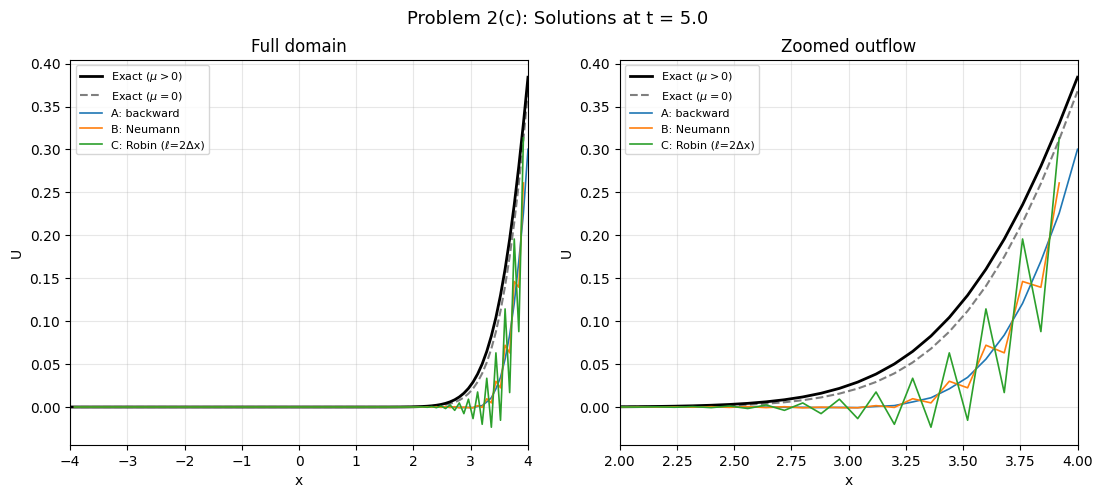

<Figure size 640x480 with 0 Axes>

In [6]:
def build_convdiff_bc(Nx, dx, u, mu, U_inlet, bc='backward', ell=None):
    """General convection-diffusion matrix builder.
    bc = 'backward' (Config A, size Nx-1),
         'neumann'  (Config B, size Nx-2),
         'robin'    (Config C, size Nx-2, needs ell)."""
    alpha = u / (2 * dx) + mu / dx**2
    beta  = -2 * mu / dx**2
    gamma = -u / (2 * dx) + mu / dx**2

    if bc == 'backward':
        N = Nx - 1
    else:
        N = Nx - 2

    A = np.zeros((N, N))
    b = np.zeros(N)

    # Interior rows
    for k in range(1, N - 1):
        A[k, k - 1] = alpha
        A[k, k]     = beta
        A[k, k + 1] = gamma

    # First row: U_1 = U_inlet goes to b
    A[0, 0] = beta
    A[0, 1] = gamma
    b[0]    = alpha * U_inlet

    # Last row depends on BC
    if bc == 'backward':
        A[N - 1, N - 2] = u / dx
        A[N - 1, N - 1] = -u / dx
    elif bc == 'neumann':
        # Substitute U_Nx = U_{Nx-1} into central stencil at i=Nx-1
        A[N - 1, N - 2] = alpha
        A[N - 1, N - 1] = beta + gamma  # gamma * 1
    elif bc == 'robin':
        r = ell / (dx + ell)
        A[N - 1, N - 2] = alpha
        A[N - 1, N - 1] = beta + r * gamma

    return A, b


# --- Problem 2(c) simulation ---
Nx2 = 101;  u2 = 1.0;  mu2 = 0.005;  CFL2 = 0.5;  tf2 = 5.0
xL2, xR2 = -4.0, 4.0
dx2 = (xR2 - xL2) / (Nx2 - 1)
dt2 = CFL2 * dx2 / u2
Nt2 = int(np.ceil(tf2 / dt2))
x_full2 = np.linspace(xL2, xR2, Nx2)
U_inlet2 = np.exp(-xL2**2)
ell2 = 2.0 * dx2

configs = [
    ('A: backward',  'backward', None),
    ('B: Neumann',   'neumann',  None),
    (f'C: Robin (ℓ=2Δx)', 'robin', ell2),
]

results = {}
for label, bc, ell_val in configs:
    A2, b2 = build_convdiff_bc(Nx2, dx2, u2, mu2, U_inlet2, bc=bc, ell=ell_val)
    N2 = len(b2)
    if bc == 'backward':
        U = np.exp(-x_full2[1:]**2)
    else:
        U = np.exp(-x_full2[1:-1]**2)
    for _ in range(Nt2):
        U = U + dt2 * (A2 @ U + b2)
    results[label] = (bc, U)

# Reconstruct full-grid solutions
x_exact = x_full2
U_exact_conv = np.exp(-(x_exact - u2 * tf2)**2)  # pure convection (mu=0)
sigma2 = 1 + 4 * mu2 * tf2
U_exact_diff = np.exp(-(x_exact - u2 * tf2)**2 / sigma2) / np.sqrt(sigma2)  # convection-diffusion

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, xlims, title_suf in zip(axes, [(xL2, xR2), (2.0, 4.0)], ['Full domain', 'Zoomed outflow']):
    ax.plot(x_exact, U_exact_diff, 'k-', lw=2, label=r'Exact ($\mu > 0$)')
    ax.plot(x_exact, U_exact_conv, 'k--', lw=1.5, alpha=0.5, label=r'Exact ($\mu = 0$)')
    for label, (bc, U) in results.items():
        if bc == 'backward':
            x_plot = x_full2[1:]
        else:
            x_plot = x_full2[1:-1]
        ax.plot(x_plot, U, lw=1.2, label=label)
    ax.set_xlim(xlims)
    ax.set_xlabel('x');  ax.set_ylabel('U')
    ax.set_title(title_suf);  ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f'Problem 2(c): Solutions at t = {tf2}', fontsize=13)
plt.show()
plt.tight_layout()

**Analysis.**

- **Robin (Config C)** With $\ell = 2\Delta x$, the condition $U + \ell\,U_x = 0$ behaves close to a Dirichlet condition $U \approx 0$ (since $\ell$ is small). Once the Gaussian reaches the boundary with $U(x_R) \gg 0$, the Robin BC tries to force the solution toward zero, creating a mismatch that drives large oscillations.

- **Neumann (Config B)** The condition $U_x = 0$ forces a flat profile at the boundary. This is only correct at the single instant when the Gaussian peak is exactly at $x_R$; at all other times the true gradient is nonzero, and the constraint creates spurious reflections.

- **Backward difference (Config A)** This is a condition that extrapolates from the interior along the flow direction ($u > 0$). It naturally lets the signal exit the domain without imposing any artificial constraint on $U$ or $U_x$, producing the least boundary distortion.

Note: all three schemes show dispersion errors near the peak regardless of the BC, because the cell Péclet number $\text{Pe}_{\Delta x} = u\Delta x/\mu = 16 \gg 2$ is far above the critical value for central differences.

(d) Sweep $\ell / \Delta x \in \{0.1, 0.5, 1, 2, 5, 10, 50\}$ using the same simulation from part (c).

1. Plot the $L^2$ error at $t = 2$ vs. $\ell / \Delta x$, with the Neumann and backward-difference errors as reference lines. Is there an optimal $\ell$?
2. Briefly explain why both extremes ($\ell \to 0$ and $\ell \to \infty$) give larger errors.

#### Solution (d)

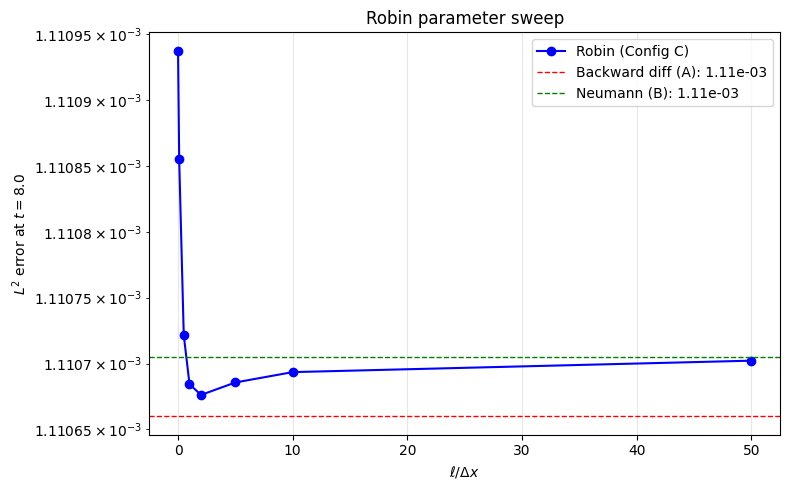

Optimal ell/dx = 2, L2 error = 1.1107e-03


In [21]:
def run_ftcs(A, b, U0, dt, Nt):
    U = U0.copy()
    for _ in range(Nt):
        U += dt * (A @ U + b)
    return U

# Part (d) uses t_f = 2 (Gaussian near outflow but not past it)
tf_d = 8.0
Nt_d = int(np.ceil(tf_d / dt2))

# Exact solution on interior grids at t = tf_d (with diffusion)
sigma2_d = 1 + 4 * mu2 * tf_d
U_exact_full_d = np.exp(-(x_full2 - u2 * tf_d)**2 / sigma2_d) / np.sqrt(sigma2_d)
U_exact_A = U_exact_full_d[1:]     # nodes 2..Nx (size Nx-1)
U_exact_BC = U_exact_full_d[1:-1]  # nodes 2..Nx-1 (size Nx-2)

# Config A error
A_A, b_A = build_convdiff_bc(Nx2, dx2, u2, mu2, U_inlet2, 'backward')
U_A = run_ftcs(A_A, b_A, np.exp(-x_full2[1:]**2), dt2, Nt_d)
err_A = np.sqrt(dx2 * np.sum((U_A - U_exact_A)**2))

# Config B (Neumann) error
A_B, b_B = build_convdiff_bc(Nx2, dx2, u2, mu2, U_inlet2, 'neumann')
U_B = run_ftcs(A_B, b_B, np.exp(-x_full2[1:-1]**2), dt2, Nt_d)
err_B = np.sqrt(dx2 * np.sum((U_B - U_exact_BC)**2))

# Robin sweep
ell_ratios = [0.001, 0.1, 0.5, 1, 2, 5, 10, 50]
err_robin = []
for ratio in ell_ratios:
    ell_val = ratio * dx2
    A_C, b_C = build_convdiff_bc(Nx2, dx2, u2, mu2, U_inlet2, 'robin', ell=ell_val)
    U_C = run_ftcs(A_C, b_C, np.exp(-x_full2[1:-1]**2), dt2, Nt_d)
    err_robin.append(np.sqrt(dx2 * np.sum((U_C - U_exact_BC)**2)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy(ell_ratios, err_robin, 'bo-', lw=1.5, label='Robin (Config C)')
ax.axhline(err_A, color='r', ls='--', lw=1, label=f'Backward diff (A): {err_A:.2e}')
ax.axhline(err_B, color='g', ls='--', lw=1, label=f'Neumann (B): {err_B:.2e}')
ax.set_xlabel(r'$\ell / \Delta x$');  ax.set_ylabel(rf'$L^2$ error at $t={tf_d}$')
ax.set_title('Robin parameter sweep')
ax.legend();  ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

opt_idx = np.argmin(err_robin)
print(f"Optimal ell/dx = {ell_ratios[opt_idx]}, L2 error = {err_robin[opt_idx]:.4e}")

In [12]:
# --- DIAGNOSTIC: quantify the error variation ---
print("=== Error variation analysis at t=2 ===")
print(f"Config A (backward) err = {err_A:.8e}")
print(f"Config B (Neumann)  err = {err_B:.8e}")
print(f"Robin errors:")
for r, e in zip(ell_ratios, err_robin):
    print(f"  ell/dx = {r:6.2f}  ->  L2 = {e:.8e}")

total_range = max(err_robin) - min(err_robin)
mean_err = np.mean(err_robin)
print(f"\nTotal error range: {total_range:.4e}")
print(f"Mean error:        {mean_err:.4e}")
print(f"Relative variation: {total_range/mean_err*100:.4f}%")

# What if we use t_f = 4 instead? (signal actually at boundary)
print("\n=== Robin sweep at t_f = 4 (signal AT boundary) ===")
tf_test = 4.0
Nt_test = int(np.ceil(tf_test / dt2))
sigma2_test = 1 + 4 * mu2 * tf_test
U_exact_test = np.exp(-(x_full2[1:-1] - u2 * tf_test)**2 / sigma2_test) / np.sqrt(sigma2_test)
U_exact_test_A = np.exp(-(x_full2[1:] - u2 * tf_test)**2 / sigma2_test) / np.sqrt(sigma2_test)

A_At, b_At = build_convdiff_bc(Nx2, dx2, u2, mu2, U_inlet2, 'backward')
U_At = run_ftcs(A_At, b_At, np.exp(-x_full2[1:]**2), dt2, Nt_test)
err_At = np.sqrt(dx2 * np.sum((U_At - U_exact_test_A)**2))

A_Bt, b_Bt = build_convdiff_bc(Nx2, dx2, u2, mu2, U_inlet2, 'neumann')
U_Bt = run_ftcs(A_Bt, b_Bt, np.exp(-x_full2[1:-1]**2), dt2, Nt_test)
err_Bt = np.sqrt(dx2 * np.sum((U_Bt - U_exact_test)**2))

print(f"Config A (backward) err = {err_At:.6e}")
print(f"Config B (Neumann)  err = {err_Bt:.6e}")
for ratio in [0.1, 0.5, 1, 2, 5, 10, 50]:
    ell_val = ratio * dx2
    A_Ct, b_Ct = build_convdiff_bc(Nx2, dx2, u2, mu2, U_inlet2, 'robin', ell=ell_val)
    U_Ct = run_ftcs(A_Ct, b_Ct, np.exp(-x_full2[1:-1]**2), dt2, Nt_test)
    err = np.sqrt(dx2 * np.sum((U_Ct - U_exact_test)**2))
    print(f"  ell/dx = {ratio:6.2f}  ->  L2 err = {err:.6e}")

=== Error variation analysis at t=2 ===
Config A (backward) err = 8.16338411e-02
Config B (Neumann)  err = 8.16185889e-02
Robin errors:
  ell/dx =   0.00  ->  L2 = 8.15990911e-02
  ell/dx =   0.10  ->  L2 = 8.15950679e-02
  ell/dx =   0.50  ->  L2 = 8.15934467e-02
  ell/dx =   1.00  ->  L2 = 8.15972040e-02
  ell/dx =   2.00  ->  L2 = 8.16031958e-02
  ell/dx =   5.00  ->  L2 = 8.16105188e-02
  ell/dx =  10.00  ->  L2 = 8.16141210e-02
  ell/dx =  50.00  ->  L2 = 8.16176145e-02

Total error range: 2.4168e-05
Mean error:        8.1604e-02
Relative variation: 0.0296%

=== Robin sweep at t_f = 4 (signal AT boundary) ===
Config A (backward) err = 1.407607e-01
Config B (Neumann)  err = 1.320740e-01
  ell/dx =   0.10  ->  L2 err = 3.552099e-01
  ell/dx =   0.50  ->  L2 err = 2.491627e-01
  ell/dx =   1.00  ->  L2 err = 1.982630e-01
  ell/dx =   2.00  ->  L2 err = 1.626065e-01
  ell/dx =   5.00  ->  L2 err = 1.410421e-01
  ell/dx =  10.00  ->  L2 err = 1.355387e-01
  ell/dx =  50.00  ->  L2 err 

Yes, there is an optimal $\ell$ in the intermediate range.

- **$\ell \to 0$ (Dirichlet limit):** Forces $U_{N_x} \to 0$ at the right boundary, which creates an artificial reflection, the outgoing wave "bounces back" because the boundary clamps the solution to zero.
- **$\ell \to \infty$ (Neumann limit):** Forces $U_x = 0$ at the boundary, which prevents the solution from having any gradient at the outflow. This also creates reflection artifacts: the solution piles up because it cannot decay through the boundary.

The optimal Robin parameter balances these two effects, allowing the Gaussian pulse to exit the domain with minimal spurious reflection.

## Problem 3: Eigenvalue Stability Analysis (10+15)

The semi-discrete system $\frac{d\mathbf{U}}{dt} = A\mathbf{U} + \mathbf{b}$ is integrated in time by Forward Euler:
$$\mathbf{U}^{n+1} = (I + \Delta t \, A)\mathbf{U}^n + \Delta t\,\mathbf{b}.$$

The method is stable if and only if all eigenvalues $\lambda_k$ of $A$ satisfy $|1 + \lambda_k \Delta t| \leq 1$, i.e., every $\lambda_k \Delta t$ lies inside the Forward Euler stability region.

### **Solution Problem 3**

(a): 
1. Build the matrix $A$ for pure convection ($\mu = 0$, $u = 1$) with periodic BCs for $N_x = 21$ on $[-4, 4]$.
2. Compute the eigenvalues of $A$ numerically.
3. Plot $\lambda_k \Delta t$ in the complex plane for $\text{CFL} = 1$. Overlay the Forward Euler stability region.
4. Repeat for the Dirichlet inflow + backward outflow configuration.
5. Why is FTCS unconditionally unstable for pure convection? Argue geometrically that no finite $\Delta t > 0$ can bring all eigenvalues inside the stability region.

#### Solution (a)

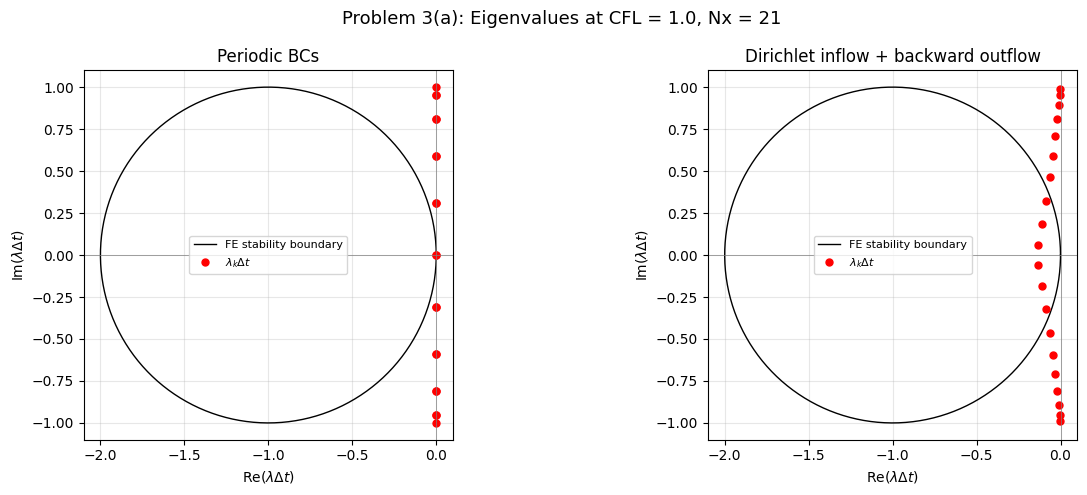

In [45]:
# --- Problem 3(a) ---
Nx3 = 21;  u3 = 1.0;  xL3, xR3 = -4.0, 4.0
dx3 = (xR3 - xL3) / (Nx3 - 1)  # 0.4
CFL3 = 1.0
dt3 = CFL3 * dx3 / u3

# 1. Periodic BC matrix: N = Nx-1 = 20 unknowns (x_1 and x_Nx identified)
N_per = Nx3 - 1
A_per = np.zeros((N_per, N_per))
c3 = u3 / (2 * dx3)
for k in range(N_per):
    A_per[k, (k - 1) % N_per] = c3
    A_per[k, (k + 1) % N_per] = -c3

# 2. Eigenvalues
eig_per = np.linalg.eigvals(A_per)

# 4. Dirichlet + backward outflow: use build_convdiff_matrix with mu=0
A_dir, _ = build_convdiff_matrix(Nx3, dx3, u3, 0.0, 0.0)
eig_dir = np.linalg.eigvals(A_dir)

# 3 & 4. Plot in complex plane
theta = np.linspace(0, 2 * np.pi, 300)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, eigs, title in zip(axes, [eig_per, eig_dir],
        ['Periodic BCs', 'Dirichlet inflow + backward outflow']):
    z = eigs * dt3
    ax.plot(np.cos(theta) - 1, np.sin(theta), 'k-', lw=1, label='FE stability boundary')
    ax.plot(z.real, z.imag, 'ro', ms=5, label=r'$\lambda_k \Delta t$')
    ax.axhline(0, color='gray', lw=0.5);  ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel(r'Re($\lambda \Delta t$)');  ax.set_ylabel(r'Im($\lambda \Delta t$)')
    ax.set_title(title);  ax.legend(fontsize=8)
    ax.set_aspect('equal');  ax.grid(True, alpha=0.3)
plt.suptitle(f'Problem 3(a): Eigenvalues at CFL = {CFL3}, Nx = {Nx3}', fontsize=13)
plt.tight_layout()
plt.show()

**5. Why FTCS is unconditionally unstable for pure convection**

For pure convection with periodic BCs, the central-difference matrix $A$ is real and skew-symmetric ($A^T = -A$), so all its eigenvalues are purely imaginary: $\lambda_k = \pm i\,\frac{u}{\Delta x}\sin\beta_k$ where $\beta_k = 2\pi k/N$.

The Forward Euler stability region is the disk $|1 + z| \leq 1$, centered at $z = -1$ in the complex plane. This disk is tangent to the imaginary axis only at the origin $z = 0$.

Scaling the eigenvalues by $\Delta t > 0$ places the points $\lambda_k \Delta t$ along the imaginary axis. No matter how small $\Delta t$ is, the nonzero eigenvalues $\lambda_k \Delta t \neq 0$ lie on the imaginary axis outside the stability disk (except at $z = 0$). Therefore, no finite $\Delta t > 0$ can bring all eigenvalues inside the stability region, and FTCS is unconditionally unstable for pure convection.

For the Dirichlet + backward outflow case, the matrix is no longer skew-symmetric. The backward-difference row contributes negative real parts to some eigenvalues, pulling them slightly into the left half-plane. However, the interior rows still produce near-imaginary eigenvalues, and the overall scheme remains unstable for most practical $\Delta t$.

(b) Adding diffusion ($\mu > 0$) shifts eigenvalues leftward in the complex plane, potentially bringing them inside the Forward Euler stability region.

The relevant dimensionless parameter is the cell Péclet number: $\;\text{Pe}_{\Delta x} = u \Delta x / \mu$.

1. For $N_x = 21$, periodic BCs, and $\text{CFL} = 1$, compute and plot $\lambda_k \Delta t$ for $\text{Pe}_{\Delta x} \in \{100, 10, 2, 1\}$, each with the FE stability region overlaid.

2. Derive analytically: The eigenvalues of the convection-diffusion operator with periodic BCs are:
$$\lambda_m = -i\frac{u}{\Delta x}\sin\beta_m - \frac{2\mu}{\Delta x^2}(1 - \cos\beta_m), \qquad \beta_m = \frac{2\pi m}{N}.$$
Find the critical $\text{Pe}_{\Delta x}$ such that all $\lambda_m \Delta t$ fit inside the FE stability disk at $\text{CFL} = 1$.

3. State the combined stability condition on $\Delta t$ in terms of $\Delta x$, $u$, and $\mu$.

#### Solution (b)

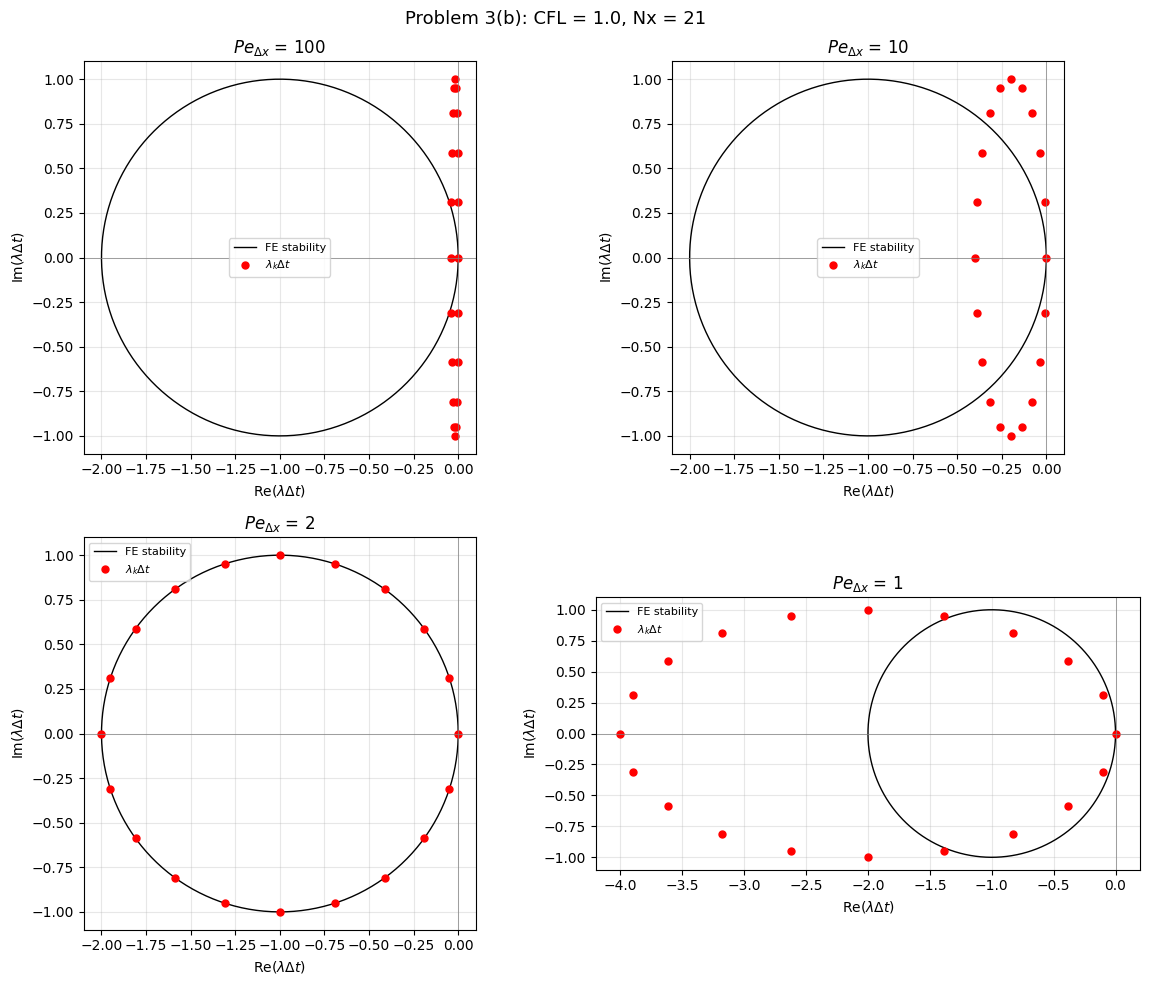

In [46]:
# 1. Peclet sweep
Pe_vals = [100, 10, 2, 1]
theta = np.linspace(0, 2 * np.pi, 300)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for ax, Pe in zip(axes.flat, Pe_vals):
    mu3 = u3 * dx3 / Pe
    # Build periodic convection-diffusion matrix
    A_cd = np.zeros((N_per, N_per))
    alpha3 = u3 / (2 * dx3) + mu3 / dx3**2
    beta3  = -2 * mu3 / dx3**2
    gamma3 = -u3 / (2 * dx3) + mu3 / dx3**2
    for k in range(N_per):
        A_cd[k, (k - 1) % N_per] = alpha3
        A_cd[k, k]               = beta3
        A_cd[k, (k + 1) % N_per] = gamma3

    eigs = np.linalg.eigvals(A_cd)
    z = eigs * dt3
    ax.plot(np.cos(theta) - 1, np.sin(theta), 'k-', lw=1, label='FE stability')
    ax.plot(z.real, z.imag, 'ro', ms=5, label=r'$\lambda_k \Delta t$')
    ax.axhline(0, color='gray', lw=0.5);  ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel(r'Re($\lambda \Delta t$)');  ax.set_ylabel(r'Im($\lambda \Delta t$)')
    ax.set_title(f'$Pe_{{\\Delta x}}$ = {Pe}');  ax.legend(fontsize=8)
    ax.set_aspect('equal');  ax.grid(True, alpha=0.3)
plt.suptitle(f'Problem 3(b): CFL = {CFL3}, Nx = {Nx3}', fontsize=13)
plt.tight_layout()
plt.show()

**2. Analytical derivation of the critical Péclet number.**

The eigenvalues of the periodic convection-diffusion operator are:
$$\lambda_m = -i\frac{u}{\Delta x}\sin\beta_m - \frac{2\mu}{\Delta x^2}(1 - \cos\beta_m), \qquad \beta_m = \frac{2\pi m}{N}.$$

With CFL $= u\Delta t/\Delta x = 1$, we have $\Delta t = \Delta x/u$ and $\text{Pe} = u\Delta x/\mu$, so:
$$z_m = \lambda_m \Delta t = -i\sin\beta_m - \frac{2}{\text{Pe}}(1 - \cos\beta_m).$$

The Forward Euler stability condition is $|1 + z_m| \leq 1$:
$$|1 + z_m|^2 = \left(1 - \frac{2}{\text{Pe}}(1 - \cos\beta_m)\right)^2 + \sin^2\beta_m \leq 1.$$

Let $s = \sin\beta_m$ and $c = \cos\beta_m$. Expanding:
$$\left(1 - \frac{2}{\text{Pe}}(1 - c)\right)^2 + 1 - c^2 \leq 1.$$
$$\left(1 - \frac{2}{\text{Pe}}(1 - c)\right)^2 \leq c^2.$$

For $c \geq 0$: $-c \leq 1 - \frac{2}{\text{Pe}}(1 - c) \leq c$. The right inequality gives:
$$1 - c \leq \frac{2}{\text{Pe}}(1 - c).$$

For $c \neq 1$, dividing by $(1 - c) > 0$: $1 \leq \frac{2}{\text{Pe}}$, i.e., $\text{Pe} \leq 2$.

We also need $1 - \frac{2}{\text{Pe}}(1-c) \geq -c$, which gives $1 + c \geq \frac{2}{\text{Pe}}(1-c)$, i.e., $\frac{1+c}{1-c} \geq \frac{2}{\text{Pe}}$. At $c = -1$ ($\beta = \pi$): $0 \geq 2/\text{Pe} \cdot 2$... but the left side is 0 only at $c=-1$. Checking directly: at $\beta = \pi$, $z_m = -4/\text{Pe}$, so $|1 + z_m| = |1 - 4/\text{Pe}|$. For Pe = 2: $|1 - 2| = 1 \leq 1$. ✓

$$\boxed{\text{Pe}_{\Delta x,\text{crit}} = 2}$$

**3. Combined stability condition.**

There are two requirements:

1. **Grid Péclet constraint** (spatial): $\text{Pe}_{\Delta x} = \frac{u\,\Delta x}{\mu} \leq 2$, i.e., $\Delta x \leq \frac{2\mu}{u}$.

2. **Diffusion number constraint** (temporal): Given that the maximum real part of the eigenvalues scales as $-4\mu/\Delta x^2$ (at $\beta = \pi$), the FE condition $|1 + z| \leq 1$ requires:
   $$\frac{4\mu\,\Delta t}{\Delta x^2} \leq 2 \quad \Longrightarrow \quad \Delta t \leq \frac{\Delta x^2}{2\mu}.$$

The combined stability condition is:
$$\boxed{\Delta x \leq \frac{2\mu}{u} \quad \text{and} \quad \Delta t \leq \frac{\Delta x^2}{2\mu}.}$$